In [3]:
import pandas as pd

# Create dataset
data = {
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10,11,12],
    "Attendance": [60,65,70,72,75,80,82,85,88,90,92,95],
    "Assignments": [2,3,4,5,5,6,7,7,8,8,9,10],
    "Marks": [35,40,45,50,58,65,72,78,82,88,92,96]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display dataset
print("Dataset Preview:")
print(df)

# Export to CSV
df.to_csv("student_performance_dataset.csv", index=False)

print("\nDataset exported successfully as 'student_performance_dataset.csv'")

Dataset Preview:
    Study_Hours  Attendance  Assignments  Marks
0             1          60            2     35
1             2          65            3     40
2             3          70            4     45
3             4          72            5     50
4             5          75            5     58
5             6          80            6     65
6             7          82            7     72
7             8          85            7     78
8             9          88            8     82
9            10          90            8     88
10           11          92            9     92
11           12          95           10     96

Dataset exported successfully as 'student_performance_dataset.csv'


In [4]:
print(df.head())#first 5 rows

   Study_Hours  Attendance  Assignments  Marks
0            1          60            2     35
1            2          65            3     40
2            3          70            4     45
3            4          72            5     50
4            5          75            5     58


In [5]:
print(df.tail())#last 5 rows

    Study_Hours  Attendance  Assignments  Marks
7             8          85            7     78
8             9          88            8     82
9            10          90            8     88
10           11          92            9     92
11           12          95           10     96


In [6]:
print(df.shape)#to identify no. of rows and cols

(12, 4)


In [7]:
print(df.columns)#to know which colums are present

Index(['Study_Hours', 'Attendance', 'Assignments', 'Marks'], dtype='object')


In [8]:
print(df.dtypes)#to know the data types

Study_Hours    int64
Attendance     int64
Assignments    int64
Marks          int64
dtype: object


In [9]:
print("\nSummary Statistics")
print(df.describe())#for summary


Summary Statistics
       Study_Hours  Attendance  Assignments      Marks
count    12.000000   12.000000    12.000000  12.000000
mean      6.500000   79.500000     6.166667  66.750000
std       3.605551   11.172206     2.443296  21.080474
min       1.000000   60.000000     2.000000  35.000000
25%       3.750000   71.500000     4.750000  48.750000
50%       6.500000   81.000000     6.500000  68.500000
75%       9.250000   88.500000     8.000000  83.500000
max      12.000000   95.000000    10.000000  96.000000


In [10]:
X = df[['Study_Hours','Attendance','Assignments']]
y = df['Marks']

print("Features")#parameters using for prediction
print(X)

print("\nLabel")#the thing we are going to predict
print(y)

Features
    Study_Hours  Attendance  Assignments
0             1          60            2
1             2          65            3
2             3          70            4
3             4          72            5
4             5          75            5
5             6          80            6
6             7          82            7
7             8          85            7
8             9          88            8
9            10          90            8
10           11          92            9
11           12          95           10

Label
0     35
1     40
2     45
3     50
4     58
5     65
6     72
7     78
8     82
9     88
10    92
11    96
Name: Marks, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42#random pick
)

print("X_train :", X_train)
print("X_test :", X_test)

print("y_train :", y_train)
print("y_test :", y_test)

X_train :     Study_Hours  Attendance  Assignments
8             9          88            8
5             6          80            6
2             3          70            4
1             2          65            3
11           12          95           10
4             5          75            5
7             8          85            7
3             4          72            5
6             7          82            7
X_test :     Study_Hours  Attendance  Assignments
10           11          92            9
9            10          90            8
0             1          60            2
y_train : 8     82
5     65
2     45
1     40
11    96
4     58
7     78
3     50
6     72
Name: Marks, dtype: int64
y_test : 10    92
9     88
0     35
Name: Marks, dtype: int64


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

print("Coefficients:")# change in study hours,attendence,assignments
print(model.coef_)

print("\nIntercept:")#change in marks
print(model.intercept_)

Coefficients:
[ 3.45487968  1.34491979 -2.40274064]

Intercept:
-48.10060160427808


In [13]:
new_data = pd.DataFrame({
    'Study_Hours':[5,8,12],
    'Attendance':[80,90,95],
    'Assignments':[5,8,10]
})

predictions = model.predict(new_data)#predictionsfor the new data

for pred in predictions:
    print(round(pred,2))#2 is taken for 2decimal places

64.75
81.36
97.1


In [14]:
predicted = model.predict(X_test)

comparison = pd.DataFrame({# Using the trained model to predict marks for the test dataset
                           # Creating a DataFrame to compare
    "Actual Marks": y_test, # True marks from the dataset
    "Predicted Marks": predicted  # Marks predicted by the model
})

comparison["Difference"] = abs(
    comparison["Actual Marks"] -
    comparison["Predicted Marks"]
)

print(comparison)
# Find the student record with the highest prediction error
max_error = comparison.loc[
    comparison["Difference"].idxmax()
]

print("\nHighest Error Student")
print(max_error)# Display details of the student with the highest prediction error

    Actual Marks  Predicted Marks  Difference
10            92        92.011029    0.011029
9             88        88.269051    0.269051
0             35        31.243984    3.756016

Highest Error Student
Actual Marks       35.000000
Predicted Marks    31.243984
Difference          3.756016
Name: 0, dtype: float64


In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,predicted)

r2 = r2_score(y_test,predicted)

print("MAE:",mae)
print("R2 Score:",r2)

MAE: 1.3453654188948292
R2 Score: 0.9929962957709836


In [16]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


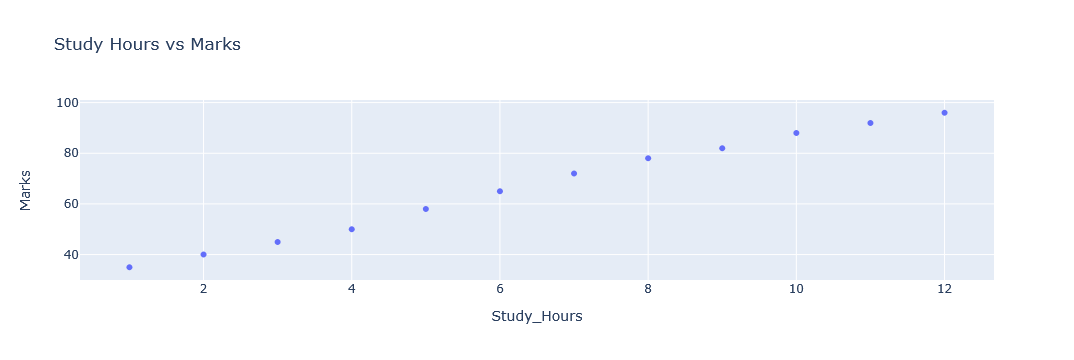

In [17]:
import plotly.express as px#plot1

fig = px.scatter(
    df,
    x="Study_Hours",
    y="Marks",
    title="Study Hours vs Marks"
)

fig.show()

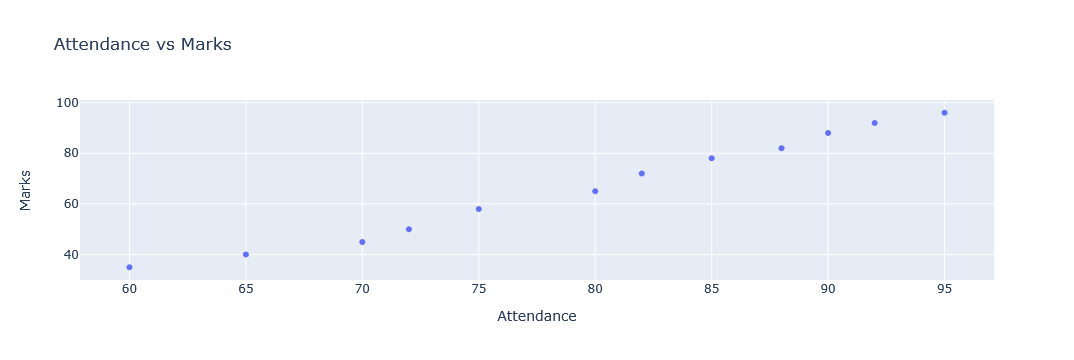

In [18]:
fig = px.scatter( #plot2
    df,
    x="Attendance",
    y="Marks",
    hover_data=df.columns,
    title="Attendance vs Marks"
)

fig.show()

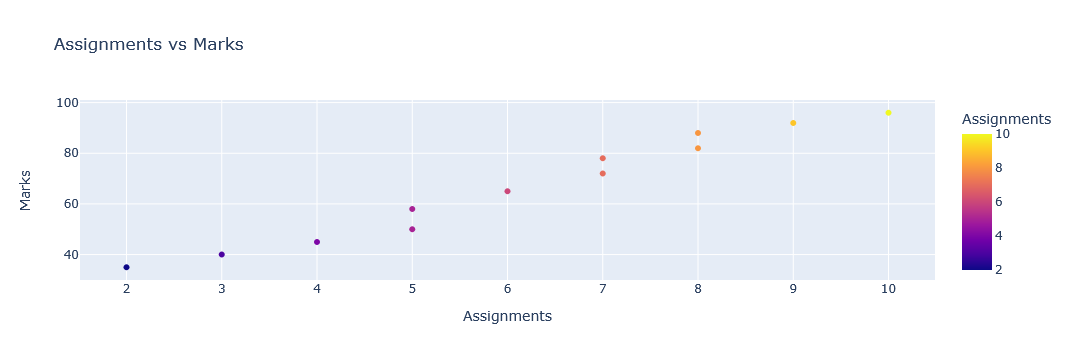

In [19]:
fig = px.scatter( #plot3
    df,
    x="Assignments",
    y="Marks",
    color="Assignments",
    title="Assignments vs Marks"
)

fig.show()

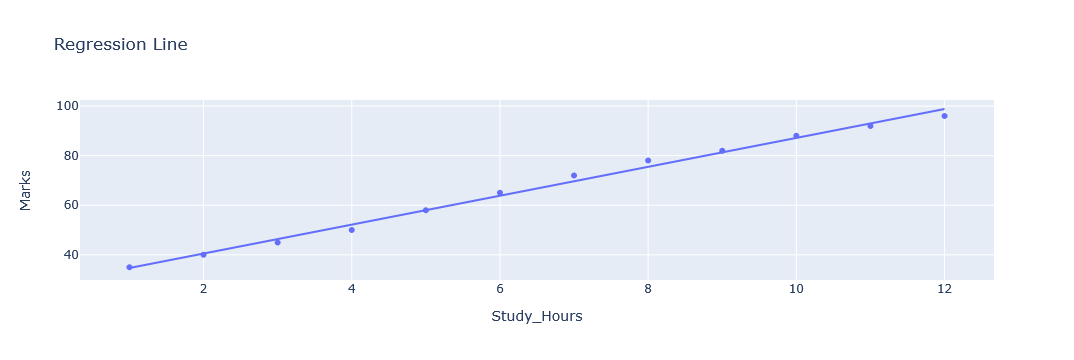

In [20]:
fig = px.scatter( #plot4
    df,
    x="Study_Hours",
    y="Marks",
    trendline="ols",
    title="Regression Line"
)

fig.show()

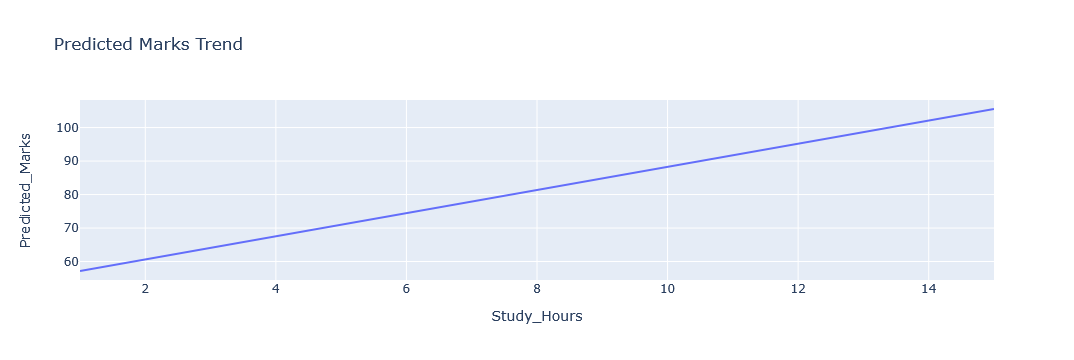

In [21]:
future = pd.DataFrame({ #plot5
    'Study_Hours':range(1,16),
    'Attendance':[90]*15,
    'Assignments':[8]*15
})

future_pred = model.predict(future)

trend = pd.DataFrame({
    "Study_Hours":range(1,16),
    "Predicted_Marks":future_pred
})

fig = px.line(
    trend,
    x="Study_Hours",
    y="Predicted_Marks",
    title="Predicted Marks Trend"
)

fig.show()

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [23]:
# Create Dataset (20 Records)
data = {
    "Area": [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600,
             900, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500, 2700],
    
    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5,
                 2, 2, 3, 3, 4, 4, 4, 5, 5, 5],
    
    "Age": [15, 12, 10, 8, 7, 6, 5, 4, 3, 2,
            14, 11, 9, 8, 6, 5, 4, 3, 2, 1],
    
    "Price": [25, 30, 38, 45, 52, 60, 68, 75, 82, 90,
              28, 34, 42, 48, 58, 65, 72, 80, 88, 95]
}


In [24]:
# Create DataFrame
df = pd.DataFrame(data)

In [25]:
print(df.head())


   Area  Bedrooms  Age  Price
0   800         2   15     25
1  1000         2   12     30
2  1200         3   10     38
3  1400         3    8     45
4  1600         3    7     52


In [26]:
# Features and Label
X = df[["Area", "Bedrooms", "Age"]]
y = df["Price"]

In [27]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [28]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
# Predictions
predictions = model.predict(X_test)


In [30]:
# Evaluation
print("\nModel Evaluation")
print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))



Model Evaluation
MAE: 0.710598942586472
R2 Score: 0.9988857343802128


In [31]:
# Comparison Table
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

print("\nComparison:")
print(comparison)



Comparison:
    Actual Price  Predicted Price
0             25        23.871560
17            80        79.594338
15            65        64.120114
1             30        30.428408


In [32]:
# Coefficients
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\nIntercept:", model.intercept_)

# New Prediction
new_house = pd.DataFrame({
    "Area": [1800],
    "Bedrooms": [4],
    "Age": [5]
})


Coefficients:
Area: 0.0381
Bedrooms: 0.9334
Age: 0.3568

Intercept: -13.855636696280385


In [33]:
predicted_price = model.predict(new_house)
